# Fake News Detection

A supervised machine-learning project that classifies news articles as **REAL** or **FAKE**
using TF-IDF text features and a `PassiveAggressiveClassifier`. This follows the classic
approach popularized by the DataFlair "Detecting Fake News" tutorial.

**Pipeline:**
1. Load and explore the dataset
2. Split into train/test sets
3. Vectorize text with TF-IDF
4. Train a Passive Aggressive Classifier
5. Evaluate accuracy, confusion matrix, and classification report
6. Try the model on a custom headline/article

> **Note on the dataset:** This notebook ships with a small *synthetic sample* dataset
> (`../data/news.csv`) so the whole pipeline runs end-to-end out of the box. For real
> results, replace it with a full-size fake news dataset (e.g. the ~6,300-article
> Kaggle "Fake News detection" dataset used in the original DataFlair tutorial) that
> has `title`, `text`, and `label` (REAL/FAKE) columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")


## 1. Load the dataset

In [2]:
df = pd.read_csv("../data/news.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (40, 4)


,Unnamed: 0,title,text,label
0,0,The national weather service issued a routine ...,The national weather service issued a routine ...,REAL
1,1,The city council voted 6-2 to approve funding ...,The city council voted 6-2 to approve funding ...,REAL
2,2,A newly released census report indicates gradu...,A newly released census report indicates gradu...,REAL
3,3,Social media posts falsely allege that a commo...,Social media posts falsely allege that a commo...,FAKE
4,4,A viral post claims eating this fruit before b...,A viral post claims eating this fruit before b...,FAKE


In [3]:
# Class balance
df["label"].value_counts()


label
REAL    20
FAKE    20
Name: count, dtype: int64

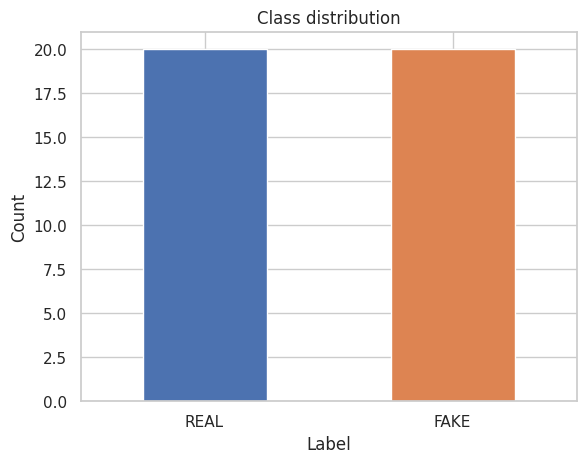

In [4]:
df["label"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Class distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 2. Train / test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=7
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 32, Test size: 8


## 3. Vectorize text with TF-IDF

`TfidfVectorizer` converts raw text into numeric feature vectors weighted by
term frequency-inverse document frequency, while `stop_words="english"` removes
common English filler words. `max_df=0.7` discards terms that appear in more
than 70% of documents (too common to be informative).


In [6]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Train matrix shape: {X_train_tfidf.shape}")


Vocabulary size: 331
Train matrix shape: (32, 331)


## 4. Train the classifier

`PassiveAggressiveClassifier` is an online learning algorithm well suited to
large-scale text classification: it stays *passive* for correct predictions
and *aggressively* updates its weights when it makes a mistake.


In [7]:
classifier = PassiveAggressiveClassifier(max_iter=50)
classifier.fit(X_train_tfidf, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Aggressiveness parameter for the passive-agressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",50
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 5. Evaluate the model

In [8]:
y_pred = classifier.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(acc * 100, 2)}%")
print()
print(classification_report(y_test, y_pred))


Accuracy: 100.0%

              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00         2
        REAL       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



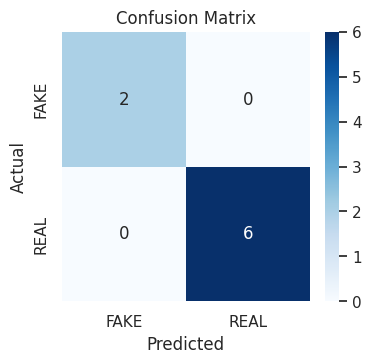

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)

plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 6. Try it on your own text

In [10]:
def predict_news(text: str) -> str:
    vec = vectorizer.transform([text])
    return classifier.predict(vec)[0]

sample_text = "Scientists confirm a new vaccine reduces hospitalization rates in a large clinical trial."
print(predict_news(sample_text))


FAKE


## 7. Save the model

Persist the fitted vectorizer and classifier so they can be reused without
retraining (see `model/train.py` for the equivalent script version).


In [11]:
import pickle

with open("../model/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("../model/classifier.pkl", "wb") as f:
    pickle.dump(classifier, f)

print("Model saved to ../model/")


Model saved to ../model/
